# Picking up with yesterday's matplotlib example

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
nw = pd.read_csv("northwind_example.csv")
nw['LineTotal'] = nw['UnitPrice'] * nw['Quantity']
nw.head(3)

,OrderID,ProductName,UnitPrice,Quantity,LineTotal
0,10248,Queso Cabrales,14.0,12,168.0
1,10248,Singaporean Hokkien Fried Mee,9.8,10,98.0
2,10248,Mozzarella di Giovanni,34.8,5,174.0


In [3]:
prod_by_rev = nw.groupby('ProductName')[['Quantity', 'LineTotal']].sum()
prod_by_rev.columns = ['Total Qty Sold', 'Total Product Revenue']
prod_by_rev.head(3)

,Total Qty Sold,Total Product Revenue
ProductName,,
Alice Mutton,331,10327.2
Aniseed Syrup,80,640.0
Boston Crab Meat,256,3763.2


In [4]:
prod_rank = prod_by_rev[['Total Product Revenue']].rank(axis='rows').astype(int)
prod_rank.columns = ['Product Rank']
# prod_rank['Product Rank'] = prod_rank['Product Rank'].astype(int)
prod_rank.sort_values('Product Rank', ascending=True).head(3)

,Product Rank
ProductName,
Laughing Lumberjack Lager,1
Rogede sild,2
Filo Mix,3


In [5]:
nw = pd.merge(nw,prod_rank, on='ProductName')
nw.head(2)

,OrderID,ProductName,UnitPrice,Quantity,LineTotal,Product Rank
0,10248,Queso Cabrales,14.0,12,168.0,43
1,10248,Singaporean Hokkien Fried Mee,9.8,10,98.0,20


In [6]:
byqty = prod_by_rev[['Total Qty Sold']].sort_values('Total Qty Sold', ascending = False)
byqty = byqty.head(10)
byqty.head(3)

,Total Qty Sold
ProductName,
Gorgonzola Telino,458
Camembert Pierrot,430
Steeleye Stout,369


In [17]:
byqty.sort_values('Total Qty Sold', ascending=True, inplace=True)

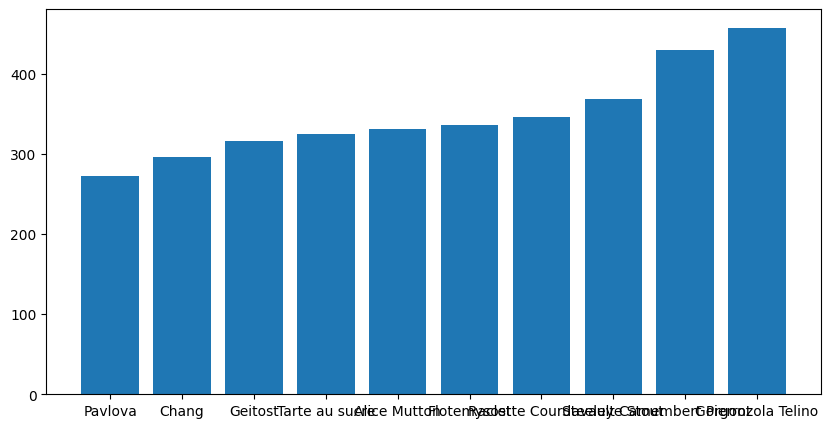

In [18]:
plt.figure(figsize=(10, 5))

plt.bar(byqty.index, byqty['Total Qty Sold'])

plt.show()

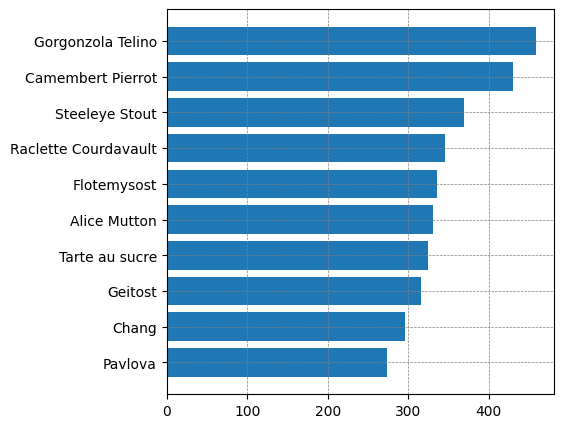

In [19]:
plt.figure(figsize=(5, 5))

plt.barh(byqty.index, byqty['Total Qty Sold'])   # turning the bar chart on its side using barh also makes the labels easier to read
plt.grid(color = 'gray', linestyle = '--', linewidth = .5)
plt.show()

In [20]:
# adding top 10 by revenue

byrev = prod_by_rev[['Total Product Revenue']].sort_values('Total Product Revenue', ascending=False).head(10)
byrev

,Total Product Revenue
ProductName,
Cte de Blaye,50381.2
Raclette Courdavault,15224.0
Thringer Rostbratwurst,14256.0
Tarte au sucre,12805.0
Camembert Pierrot,11696.0
Alice Mutton,10327.2
Gnocchi di nonna Alice,8177.6
Mozzarella di Giovanni,7541.0
Vegie-spread,7335.9


In [21]:
byqtyall = prod_by_rev[['Total Qty Sold']].sort_values('Total Qty Sold', ascending = False)
byqtyall

,Total Qty Sold
ProductName,
Gorgonzola Telino,458
Camembert Pierrot,430
Steeleye Stout,369
Raclette Courdavault,346
Flotemysost,336
...,...
Gustaf's Knckebrd,18
Sirop d'rable,16
Rogede sild,15


In [11]:
# merging top by qty and by rev

top10 = byrev.join(byqtyall[['Total Qty Sold']],how='left')
top10

,Total Product Revenue,Total Qty Sold
ProductName,,
Cte de Blaye,50381.2,239
Raclette Courdavault,15224.0,346
Thringer Rostbratwurst,14256.0,144
Tarte au sucre,12805.0,325
Camembert Pierrot,11696.0,430
Alice Mutton,10327.2,331
Gnocchi di nonna Alice,8177.6,269
Mozzarella di Giovanni,7541.0,270
Vegie-spread,7335.9,209


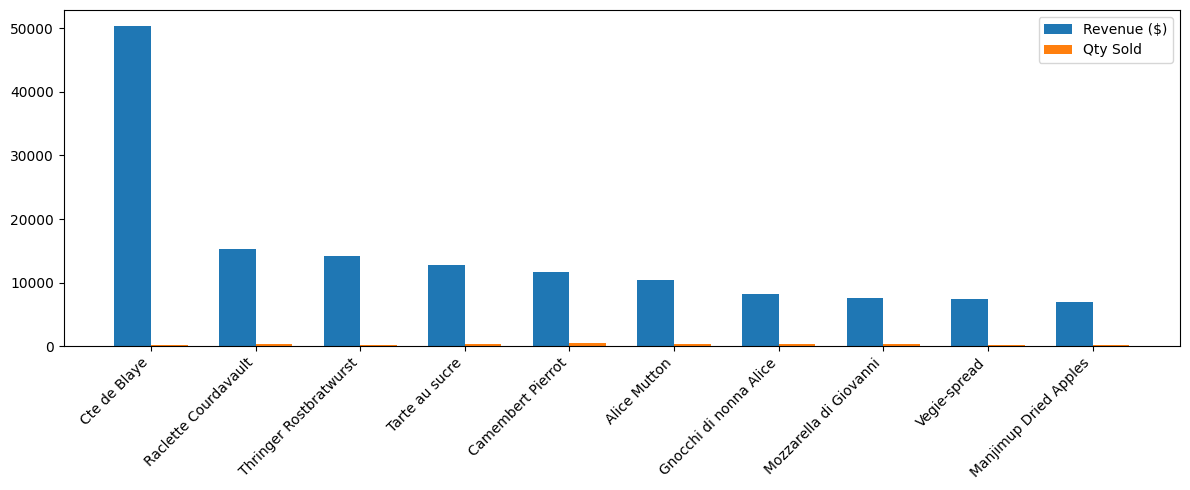

In [26]:
x = np.arange(len(top10.index))
width = .35

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width/2, top10['Total Product Revenue'], width, label='Revenue ($)')
ax.bar(x + width/2, top10['Total Qty Sold'],        width, label='Qty Sold')

ax.set_xticks(x)
ax.set_xticklabels(top10.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

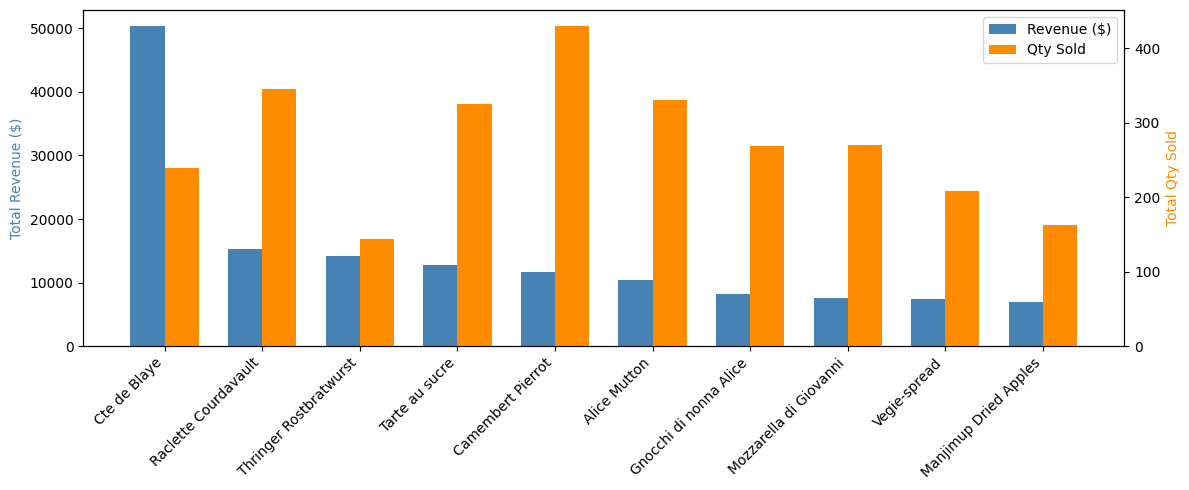

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(x - width/2, top10['Total Product Revenue'], width,
        label='Revenue ($)', color='steelblue')
ax2.bar(x + width/2, top10['Total Qty Sold'],        width,
        label='Qty Sold', color='darkorange')

ax1.set_ylabel('Total Revenue ($)', color='steelblue')
ax2.set_ylabel('Total Qty Sold',    color='darkorange')
ax1.set_xticks(x)
ax1.set_xticklabels(top10.index, rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

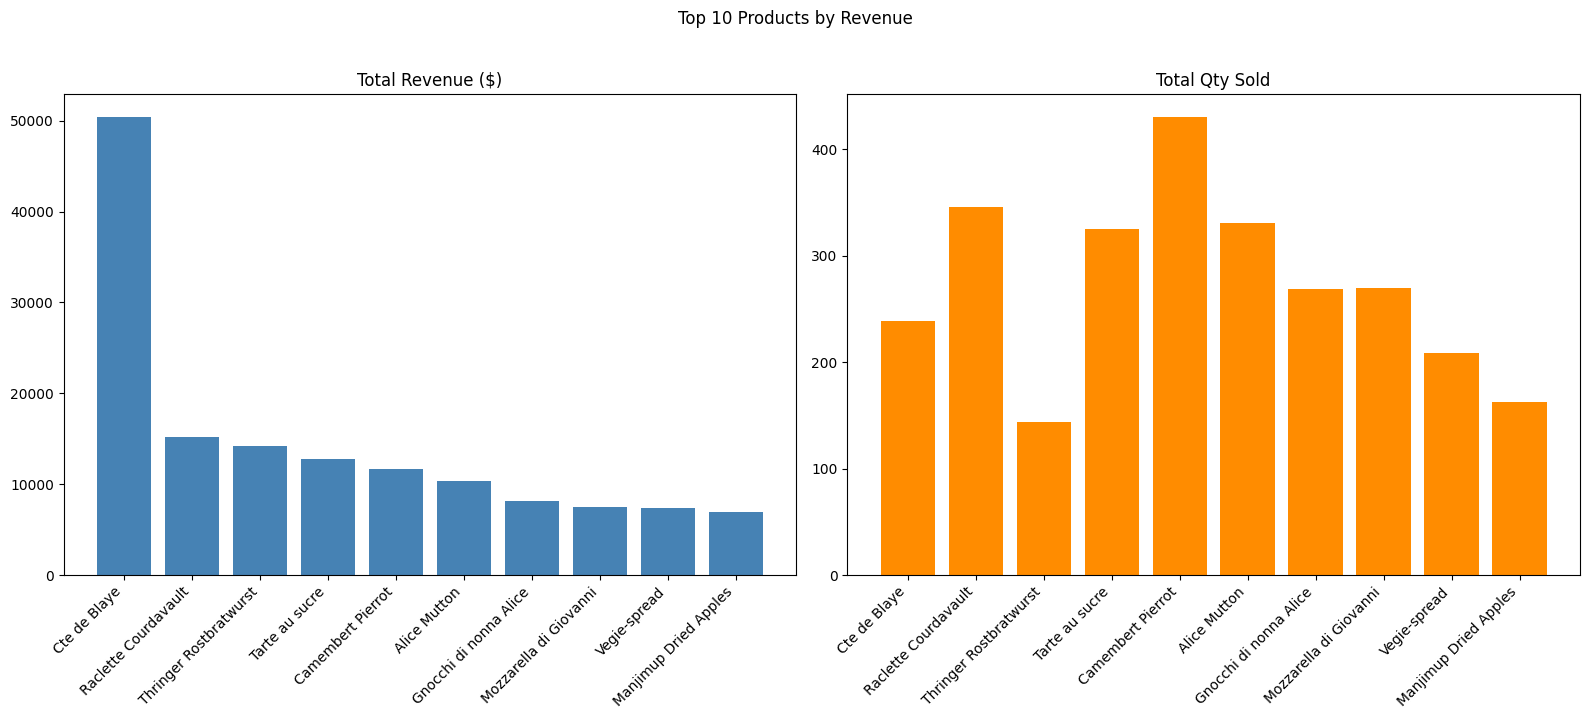

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left axes — Revenue
ax1.bar(top10.index, top10['Total Product Revenue'], color='steelblue')
# ax1.set_ylim(0, 20000)
# ax1.annotate('$52k', xy=(0, 19000), fontsize=14, va='top', color='white', ha='center')
ax1.set_title('Total Revenue ($)')
ax1.set_xticks(x)
ax1.set_xticklabels(top10.index, rotation=45, ha='right')

# Right axes — Quantity
ax2.bar(top10.index, top10['Total Qty Sold'], color='darkorange')
ax2.set_title('Total Qty Sold')
ax2.set_xticks(x)
ax2.set_xticklabels(top10.index, rotation=45, ha='right')

plt.suptitle('Top 10 Products by Revenue', y=1.02)
plt.tight_layout()
plt.show()

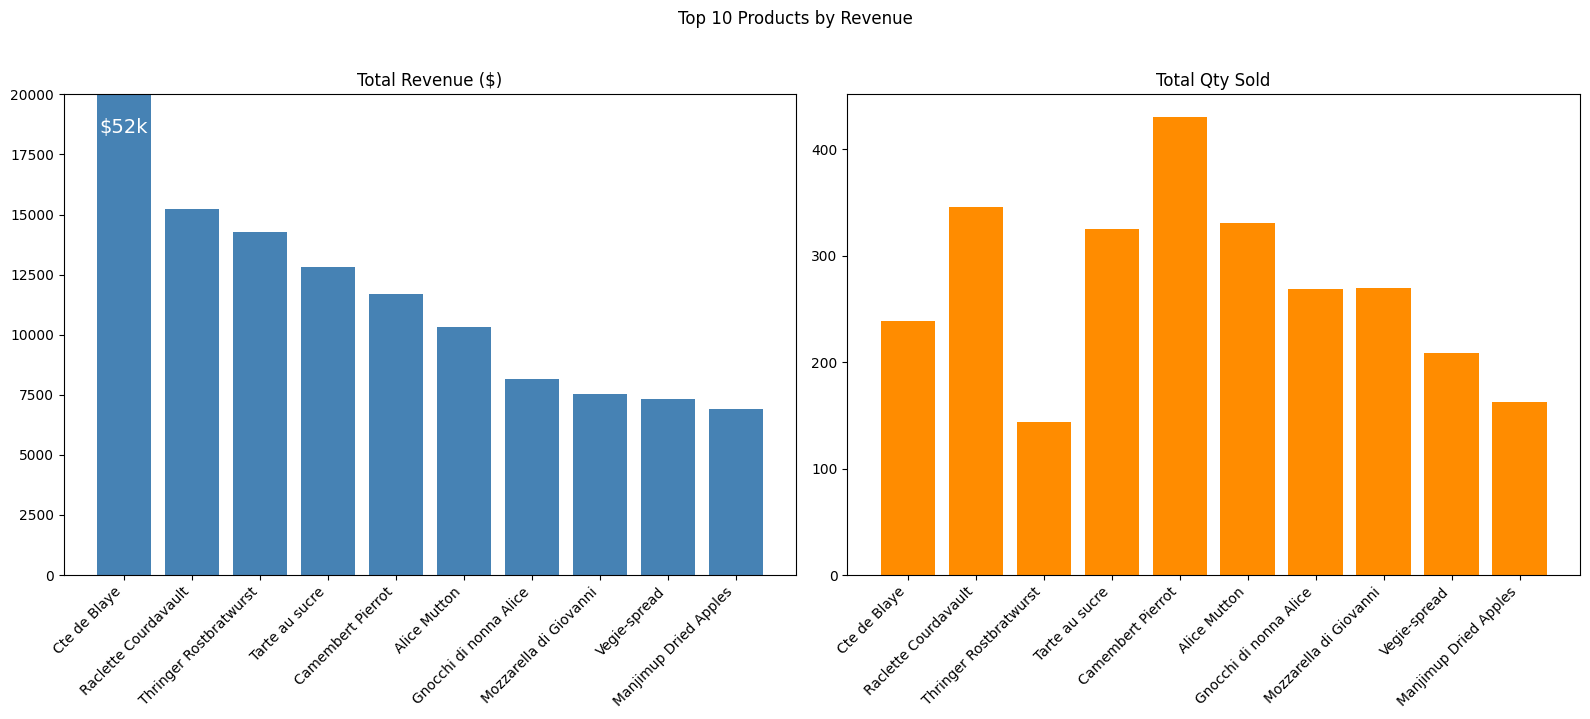

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left axes — Revenue
ax1.bar(top10.index, top10['Total Product Revenue'], color='steelblue')
ax1.set_ylim(0, 20000)
ax1.annotate('$52k', xy=(0, 19000), fontsize=14, va='top', color='white', ha='center')
ax1.set_title('Total Revenue ($)')
ax1.set_xticks(x)
ax1.set_xticklabels(top10.index, rotation=45, ha='right')

# Right axes — Quantity
ax2.bar(top10.index, top10['Total Qty Sold'], color='darkorange')
ax2.set_title('Total Qty Sold')
ax2.set_xticks(x)
ax2.set_xticklabels(top10.index, rotation=45, ha='right')

plt.suptitle('Top 10 Products by Revenue', y=1.02)
plt.tight_layout()
plt.savefig('my_awesome_chart.jpg')
plt.show()